
# Actividad 5. Técnicas de visualización de resultados en Big Data


**Instituto Tecnológico y de Estudios Superiores de Monterrey**  
**Maestría en Inteligencia Artificial Aplicada**  
**Análisis de grandes volúmenes de datos**  
**Docente:** Dr. Iván Olmos Pineda

* Vega Martínez, Ángel — A01377304

**Fecha:** 22 de junio de 2026

## Introducción

En esta actividad se retoma el mejor algoritmo identificado en la Etapa 3 del proyecto: **K-Means con K = 5**, seleccionado por haber obtenido el mejor desempeño en términos de **Silhouette Score en TEST = 0.4267**, por encima de Bisecting K-Means (**0.3281**). Además, en la Etapa 3 se trabajó con una muestra **M = 945,732 registros** derivada de un dataset original de **9,442,956 registros**, construida mediante muestreo estratificado adaptativo sobre **97 estratos** definidos por las variables `CategoryGroup`, `EntityTypeGroup` y `EvidenceRole`. Estos elementos serán la base para definir una estrategia de **validación cruzada estratificada** orientada a medir la variabilidad de los resultados del modelo.




## Muestra M

In [1]:

# ==============================
# 0. Configuración del entorno
# ==============================

!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-17-openjdk-amd64'
os.environ['SPARK_HOME'] = '/content/spark-3.5.8-bin-hadoop3'

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.master('local[*]').appName('Actividad5_Visualizacion_Resultados').getOrCreate()
spark.conf.set('spark.sql.repl.eagerEval.enabled', True)

from pyspark import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

print('Spark listo:', spark.version)


Spark listo: 3.5.8


In [3]:

# =======================================
# 0.1 Carga del dataset original
# =======================================

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Definir ruta del archivo
file_path = "/content/drive/MyDrive/Colab Notebooks/Análisis de grandes volúmenes de datos (Gpo 10)/Microsoft_GUIDE_Train.csv"

df = spark.read.csv(file_path, header=True, inferSchema=True)
df.limit(2).toPandas()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04 06:05:15,7,6,InitialAccess,None,TruePositive,...,None,None,5,66,None,None,None,31,6,3
1,455266534868,88,326,210035,2024-06-14 03:01:25,58,43,Exfiltration,None,FalsePositive,...,None,None,5,66,None,None,None,242,1445,10630


In [4]:

# =======================================
# 0.2 Preprocesamiento y construcción de M
# =======================================

from pyspark.sql.functions import col, when, hour, dayofweek, month, concat_ws
df = df.filter(F.col('IncidentGrade').isNotNull())
df = df.dropDuplicates()
df = df.filter(F.col('Timestamp').isNotNull())
cols_to_drop = ['ActionGrouped', 'ActionGranular', 'EmailClusterId', 'ResourceType', 'Roles', 'AntispamDirection', 'ThreatFamily']
df = df.drop(*cols_to_drop)
fill_values = {'MitreTechniques': 'Unknown', 'SuspicionLevel': 'Unknown', 'LastVerdict': 'Unknown'}
df = df.fillna(fill_values)
df = df.withColumn('EventHour', hour(F.col('Timestamp')))
df = df.withColumn('EventDayOfWeek', dayofweek(F.col('Timestamp')))
df = df.withColumn('EventMonth', month(F.col('Timestamp')))
top_categories = [row['Category'] for row in df.groupBy('Category').count().orderBy(F.col('count').desc()).limit(25).collect()]
df = df.withColumn('CategoryReduced', F.when(F.col('Category').isin(top_categories), F.col('Category')).otherwise('OtherCategory'))
top_categories_sampling = [row['Category'] for row in df.groupBy('Category').count().orderBy(F.col('count').desc()).limit(10).collect()]
top_entity_types = [row['EntityType'] for row in df.groupBy('EntityType').count().orderBy(F.col('count').desc()).limit(5).collect()]
df = df.withColumn('CategoryGroup', F.when(F.col('Category').isin(top_categories_sampling), F.col('Category')).otherwise('OtherCategory'))
df = df.withColumn('EntityTypeGroup', F.when(F.col('EntityType').isin(top_entity_types), F.col('EntityType')).otherwise('Other'))
df = df.withColumn('Stratum', concat_ws('_', F.col('CategoryGroup'), F.col('EntityTypeGroup'), F.col('EvidenceRole')))
total_records = df.count()
strata_counts = df.groupBy('Stratum').count().cache()
fractions = {}
for row in strata_counts.collect():
  n = row['count']
  fractions[row['Stratum']] = 1.0 if n < 100 else (0.30 if n < 1000 else 0.10)
sample_M = df.sampleBy('Stratum', fractions=fractions, seed=42)
sample_M.persist(StorageLevel.MEMORY_AND_DISK)
print(f'Total registros dataset original: {total_records:,}')
print(f'Total registros muestra M: {sample_M.count():,}')

sample_M.printSchema()
sample_M.count()

Total registros dataset original: 9,442,956
Total registros muestra M: 945,732
root
 |-- Id: long (nullable = true)
 |-- OrgId: integer (nullable = true)
 |-- IncidentId: integer (nullable = true)
 |-- AlertId: integer (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- DetectorId: integer (nullable = true)
 |-- AlertTitle: integer (nullable = true)
 |-- Category: string (nullable = true)
 |-- MitreTechniques: string (nullable = false)
 |-- IncidentGrade: string (nullable = true)
 |-- EntityType: string (nullable = true)
 |-- EvidenceRole: string (nullable = true)
 |-- DeviceId: integer (nullable = true)
 |-- Sha256: integer (nullable = true)
 |-- IpAddress: integer (nullable = true)
 |-- Url: integer (nullable = true)
 |-- AccountSid: integer (nullable = true)
 |-- AccountUpn: integer (nullable = true)
 |-- AccountObjectId: integer (nullable = true)
 |-- AccountName: integer (nullable = true)
 |-- DeviceName: integer (nullable = true)
 |-- NetworkMessageId: integer (nul

945732


# 1. Cálculo del valor K para validación cruzada


En la **Etapa 3** se demostró que el algoritmo con mejor capacidad de agrupamiento fue **K-Means con K = 5**. La nueva tarea no consiste en volver a seleccionar otro algoritmo, sino en **medir la variabilidad de sus resultados** cuando el entrenamiento y la validación cambian de una partición a otra.

La validación cruzada más adecuada para este caso es una **validación cruzada estratificada manual**, construida sobre la muestra **M**, respetando los mismos estratos definidos previamente por:

- `CategoryGroup`
- `EntityTypeGroup`
- `EvidenceRole`

Estas variables describen dimensiones estructurales importantes del fenómeno de ciberseguridad analizado y, por lo tanto, son las más convenientes para preservar representatividad al construir los folds.


Se propone utilizar **k = 5 folds**, por las siguientes razones:

La muestra M contiene aproximadamente **945,732 registros** distribuidos en **97 estratos**. Si se elige `k = 5`, cada fold contendrá en promedio alrededor de **189 mil registros**, mientras que cada conjunto de entrenamiento utilizará cerca del **80% de la muestra** (~756 mil registros). Esta proporción es suficientemente grande para que K-Means aprenda patrones robustos y, al mismo tiempo, deja un bloque de validación amplio para medir estabilidad.

Con 97 estratos, algunos grupos tienen menor tamaño relativo. Si se utilizara un número excesivo de folds (por ejemplo, 10), ciertos estratos pequeños podrían fragmentarse demasiado, incrementando la varianza en las métricas y debilitando la representatividad de algunos pliegues. Con `k = 5`, cada estrato puede distribuirse casi equitativamente entre los folds, minimizando ese riesgo.

En aprendizaje no supervisado sobre grandes volúmenes de datos, el costo computacional es un criterio central. Aumentar el número de folds eleva linealmente el número de entrenamientos completos. Con `k = 5`, la actividad requiere cinco iteraciones completas del pipeline (encoding, ensamblado, escalamiento, PCA, entrenamiento y evaluación), lo cual es exigente pero razonable en PySpark.

Cinco repeticiones permiten obtener medidas de variabilidad suficientemente informativas:

- media
- desviación estándar
- coeficiente de variación
- rangos por fold
- análisis del gap Train vs Validation

Estas medidas son adecuadas para argumentar si el modelo generaliza de forma consistente.



In [5]:

# =======================================
# 1.4 Verificación empírica para justificar k = 5
# =======================================

k_cv = 5
M_count = sample_M.count()
strata_count = sample_M.select('Stratum').distinct().count()
expected_fold_size = M_count / k_cv
expected_train_size = M_count * (k_cv - 1) / k_cv

print('=' * 70)
print('Justificación cuantitativa de la validación cruzada')
print('=' * 70)
print(f'Tamaño de la muestra M: {M_count:,}')
print(f'Número de estratos observados: {strata_count}')
print(f'Número de folds propuesto: {k_cv}')
print(f'Tamaño promedio esperado por fold: {expected_fold_size:,.0f}')
print(f'Tamaño promedio esperado de entrenamiento en cada iteración: {expected_train_size:,.0f}')
print('=' * 70)

strata_stats = sample_M.groupBy('Stratum').count().toPandas()
strata_stats['esperado_por_fold'] = strata_stats['count'] / k_cv
strata_stats.describe()


Justificación cuantitativa de la validación cruzada
Tamaño de la muestra M: 945,732
Número de estratos observados: 97
Número de folds propuesto: 5
Tamaño promedio esperado por fold: 189,146
Tamaño promedio esperado de entrenamiento en cada iteración: 756,586


,count,esperado_por_fold
count,97.000000,97.000000
mean,9749.814433,1949.962887
std,21557.426565,4311.485313
min,2.000000,0.400000
25%,144.000000,28.800000
50%,1512.000000,302.400000
75%,8265.000000,1653.000000
max,126973.000000,25394.600000


La validación cuantitativa muestra que k = 5 es una elección adecuada para la muestra M = 945,732 registros, distribuida en 97 estratos. Con esta configuración, cada fold contiene en promedio 189,146 observaciones, mientras que cada entrenamiento utiliza aproximadamente 756,586 registros, lo cual proporciona suficiente información para entrenar el modelo y una partición de validación amplia para medir variabilidad. Además, el análisis por estrato indica que el promedio esperado por fold es de 1,949.96 registros, con una mediana de 302.4 y un percentil 25 de 28.8, lo que sugiere que la mayoría de los estratos estarán razonablemente representados en cada pliegue. Aunque existen estratos extremadamente pequeños (mínimo = 2 registros), estos corresponden a casos raros y no comprometen la representatividad global de los folds. En consecuencia, k = 5 ofrece un equilibrio adecuado entre representatividad, estabilidad estadística y costo computacional


# 2. Construcción de los k-folds

## 2.1 Estrategia de construcción

Para construir los folds se utilizará una **asignación estratificada balanceada**.

1. Dentro de cada estrato se ordenan aleatoriamente los registros.
2. Se asigna cada registro a un fold usando una regla cíclica: `fold_id = ((row_number - 1) % k) + 1`.
3. Esto garantiza que, dentro de cada estrato, los registros se distribuyan de la forma más uniforme posible entre los 5 folds.

### Ventajas de esta construcción
- preserva la representatividad de los estratos;
- evita pliegues desbalanceados;
- garantiza que cada observación aparece exactamente una vez como validación;
- permite construir particiones reproducibles usando una semilla fija.



In [6]:

# =======================================
# 2.3 Construcción de los 5 folds estratificados
# =======================================

from pyspark.sql.functions import row_number, rand, col
from pyspark.sql.window import Window

k_cv = 5
seed_value = 42
sample_M = sample_M.withColumn('row_id', F.monotonically_increasing_id())
w = Window.partitionBy('Stratum').orderBy(rand(seed_value))

folded_df = (
    sample_M
    .withColumn('rn_in_stratum', row_number().over(w))
    .withColumn('fold_id', ((col('rn_in_stratum') - 1) % k_cv) + 1)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

print('Total registros con fold asignado:', folded_df.count())
folded_df.select('row_id', 'Stratum', 'fold_id').limit(10).toPandas()


Total registros con fold asignado: 945732


,row_id,Stratum,fold_id
0,1228360650754,CommandAndControl_Other_Impacted,1
1,120259087077,CommandAndControl_Other_Impacted,2
2,455266538071,CommandAndControl_Other_Impacted,3
3,901943136325,CommandAndControl_Other_Impacted,4
4,661424965372,CommandAndControl_Other_Impacted,5
5,180388627689,CommandAndControl_Other_Impacted,1
6,1022202216925,CommandAndControl_Other_Impacted,2
7,223338300878,CommandAndControl_Other_Impacted,3
8,755914246423,CommandAndControl_Other_Impacted,4
9,1305670061258,CommandAndControl_Other_Impacted,5


In [7]:

# 2.4 Verificación global del balance entre folds
fold_sizes = folded_df.groupBy('fold_id').count().orderBy('fold_id')
fold_sizes_pd = fold_sizes.toPandas()
fold_sizes_pd['pct'] = 100 * fold_sizes_pd['count'] / fold_sizes_pd['count'].sum()
fold_sizes_pd


,fold_id,count,pct
0,1,189187,20.004293
1,2,189162,20.001650
2,3,189147,20.000063
3,4,189130,19.998266
4,5,189106,19.995728


In [8]:

# 2.5 Verificación de representatividad por estrato
stratum_fold_dist = folded_df.groupBy('Stratum', 'fold_id').count()
stratum_total = folded_df.groupBy('Stratum').count().withColumnRenamed('count', 'stratum_total')
repr_df = (
    stratum_fold_dist
    .join(stratum_total, on='Stratum', how='left')
    .withColumn('pct_in_stratum', F.round(100 * F.col('count') / F.col('stratum_total'), 2))
    .orderBy('Stratum', 'fold_id')
)
repr_df.limit(20).toPandas()


,Stratum,fold_id,count,stratum_total,pct_in_stratum
0,CommandAndControl_File_Related,1,33,165,20.00
1,CommandAndControl_File_Related,2,33,165,20.00
2,CommandAndControl_File_Related,3,33,165,20.00
3,CommandAndControl_File_Related,4,33,165,20.00
4,CommandAndControl_File_Related,5,33,165,20.00
5,CommandAndControl_Ip_Related,1,2583,12911,20.01
6,CommandAndControl_Ip_Related,2,2582,12911,20.00
7,CommandAndControl_Ip_Related,3,2582,12911,20.00
8,CommandAndControl_Ip_Related,4,2582,12911,20.00
9,CommandAndControl_Ip_Related,5,2582,12911,20.00


In [9]:

# 2.6 Resumen estadístico de representatividad
repr_pd = repr_df.toPandas()
summary_repr = repr_pd.groupby('fold_id')['pct_in_stratum'].agg(['mean', 'std', 'min', 'max']).reset_index()
summary_repr


,fold_id,mean,std,min,max
0,1,20.716701,3.362322,20.00,50.0
1,2,20.393093,3.111954,16.67,50.0
2,3,20.062604,0.680336,16.67,25.0
3,4,19.972708,0.705901,16.67,25.0
4,5,19.672316,0.872901,14.29,20.0


En síntesis, la construcción de los folds cumple satisfactoriamente con los objetivos metodológicos de la actividad. Cada observación fue asignada a un único pliegue, la distribución global entre folds es prácticamente uniforme y la representatividad por estrato se conserva de forma adecuada incluso en presencia de subgrupos poco frecuentes. Por tanto, los folds generados constituyen una base válida para realizar experimentación con validación cruzada sobre el modelo K-Means seleccionado en la Etapa 3.


# 3. Experimentación con Validación Cruzada

## 3.1 Diseño experimental

En cada iteración de la validación cruzada se hará lo siguiente:

1. Tomar **1 fold como validación**.
2. Tomar los **4 folds restantes como entrenamiento**.
3. Ajustar el pipeline del modelo únicamente con los datos de entrenamiento:
   - Frequency Encoding
   - VectorAssembler
   - StandardScaler
   - PCA
   - K-Means (K = 5)
4. Evaluar por separado el desempeño en **Train** y **Validation**.
5. Registrar métricas por fold.

## 3.2 Métricas a utilizar

Se utilizarán las métricas que fueron seleccionadas como las más apropiadas en la Etapa 3:

- **Silhouette Score** (mayor es mejor)
- **Davies-Bouldin Index** (menor es mejor)
- **Calinski-Harabasz Index** (mayor es mejor)
- **WSSSE / Training Cost** de K-Means (menor es mejor, útil como referencia adicional)
- **Gap Train-Val** en Silhouette para estudiar estabilidad y posible sobreajuste


In [10]:

# 3.4 Definición de variables del modelo
categorical_cols = ['CategoryReduced', 'MitreTechniques', 'EntityType', 'EvidenceRole', 'SuspicionLevel', 'LastVerdict']
numeric_cols = ['EventHour', 'EventDayOfWeek', 'EventMonth']
feature_cols_encoded = [f'{c}_freq' for c in categorical_cols] + numeric_cols
k_clusters = 5
pca_components = 5
seed_value = 42


In [11]:

# 3.5 Funciones auxiliares
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

def apply_frequency_encoding(train_df, valid_df, categorical_cols):
    for c in categorical_cols:
        freq_df = train_df.groupBy(c).count().withColumnRenamed('count', f'{c}_freq')
        train_df = train_df.join(freq_df, on=c, how='left').fillna({f'{c}_freq': 0})
        valid_df = valid_df.join(freq_df, on=c, how='left').fillna({f'{c}_freq': 0})
    return train_df, valid_df


def build_feature_pipeline(train_df, valid_df, feature_cols, pca_components=5):
    assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
    train_df = assembler.transform(train_df)
    valid_df = assembler.transform(valid_df)
    scaler = StandardScaler(inputCol='features', outputCol='scaledFeatures', withStd=True, withMean=True)
    scaler_model = scaler.fit(train_df)
    train_df = scaler_model.transform(train_df)
    valid_df = scaler_model.transform(valid_df)
    pca = PCA(k=pca_components, inputCol='scaledFeatures', outputCol='pcaFeatures')
    pca_model = pca.fit(train_df)
    train_df = pca_model.transform(train_df)
    valid_df = pca_model.transform(valid_df)
    return train_df, valid_df, scaler_model, pca_model


def evaluate_clustering_spark(pred_df, features_col='pcaFeatures', prediction_col='prediction'):
    evaluator = ClusteringEvaluator(featuresCol=features_col, predictionCol=prediction_col, metricName='silhouette', distanceMeasure='squaredEuclidean')
    return evaluator.evaluate(pred_df)


def sample_for_external_metrics(pred_df, features_col='pcaFeatures', prediction_col='prediction', max_rows=100000, seed=42):
    total = pred_df.count()
    frac = min(1.0, max_rows / total) if total > 0 else 1.0
    sampled = pred_df.sample(withReplacement=False, fraction=frac, seed=seed)
    sampled_pd = sampled.select(vector_to_array(features_col).alias('features'), prediction_col).toPandas()
    X = np.vstack(sampled_pd['features'].values)
    y = sampled_pd[prediction_col].values
    return X, y, len(sampled_pd)


In [12]:

# 3.6 Ejecución de la validación cruzada estratificada
results = []

for fold in range(1, k_cv + 1):
    print('=' * 90)
    print(f'Iteración de validación cruzada - Fold {fold}/{k_cv}')
    print('=' * 90)
    train_fold = folded_df.filter(F.col('fold_id') != fold)
    valid_fold = folded_df.filter(F.col('fold_id') == fold)
    train_count = train_fold.count()
    valid_count = valid_fold.count()
    print(f'Train: {train_count:,} | Validation: {valid_count:,}')
    start_time = time.time()
    train_encoded, valid_encoded = apply_frequency_encoding(train_fold, valid_fold, categorical_cols)
    train_ready, valid_ready, scaler_model, pca_model = build_feature_pipeline(train_encoded, valid_encoded, feature_cols_encoded, pca_components=pca_components)
    kmeans = KMeans(k=k_clusters, seed=seed_value, maxIter=20, featuresCol='pcaFeatures', predictionCol='prediction')
    model = kmeans.fit(train_ready)
    train_pred = model.transform(train_ready)
    valid_pred = model.transform(valid_ready)
    train_silhouette = evaluate_clustering_spark(train_pred)
    valid_silhouette = evaluate_clustering_spark(valid_pred)
    gap_silhouette = abs(train_silhouette - valid_silhouette)
    training_cost = float(model.summary.trainingCost)
    X_val, y_val, n_external = sample_for_external_metrics(valid_pred, max_rows=100000, seed=seed_value)
    dbi_val = davies_bouldin_score(X_val, y_val)
    ch_val = calinski_harabasz_score(X_val, y_val)
    elapsed = time.time() - start_time
    results.append({
        'fold': fold,
        'train_count': train_count,
        'valid_count': valid_count,
        'train_silhouette': train_silhouette,
        'valid_silhouette': valid_silhouette,
        'gap_silhouette': gap_silhouette,
        'dbi_valid': dbi_val,
        'ch_valid': ch_val,
        'training_cost': training_cost,
        'external_metric_sample_size': n_external,
        'runtime_sec': elapsed
    })
    print(f'Silhouette Train: {train_silhouette:.4f}')
    print(f'Silhouette Validation: {valid_silhouette:.4f}')
    print(f'Gap Train-Val: {gap_silhouette:.4f}')
    print(f'Davies-Bouldin (Validation): {dbi_val:.4f}')
    print(f'Calinski-Harabasz (Validation): {ch_val:.4f}')
    print(f'Training Cost: {training_cost:,.2f}')
    print(f'Tiempo de ejecución: {elapsed:.2f} segundos')


Iteración de validación cruzada - Fold 1/5
Train: 756,545 | Validation: 189,187
Silhouette Train: 0.4292
Silhouette Validation: 0.4293
Gap Train-Val: 0.0001
Davies-Bouldin (Validation): 1.3468
Calinski-Harabasz (Validation): 35358.2474
Training Cost: 2,156,227.03
Tiempo de ejecución: 375.63 segundos
Iteración de validación cruzada - Fold 2/5
Train: 756,570 | Validation: 189,162
Silhouette Train: 0.3537
Silhouette Validation: 0.3543
Gap Train-Val: 0.0006
Davies-Bouldin (Validation): 1.5138
Calinski-Harabasz (Validation): 19811.0439
Training Cost: 2,909,519.72
Tiempo de ejecución: 367.88 segundos
Iteración de validación cruzada - Fold 3/5
Train: 756,585 | Validation: 189,147
Silhouette Train: 0.4118
Silhouette Validation: 0.4118
Gap Train-Val: 0.0000
Davies-Bouldin (Validation): 1.4526
Calinski-Harabasz (Validation): 30712.7423
Training Cost: 2,343,563.41
Tiempo de ejecución: 354.44 segundos
Iteración de validación cruzada - Fold 4/5
Train: 756,602 | Validation: 189,130
Silhouette Train:

La validación cruzada mostró que el modelo K-Means con K = 5 mantiene un comportamiento muy estable entre entrenamiento y validación. En los cinco folds, el gap Train-Val fue prácticamente nulo, lo que indica que no existe evidencia de sobreajuste.
Sin embargo, sí se observa variabilidad en la calidad del agrupamiento entre folds. Los mejores resultados se obtuvieron en los folds 1 y 5, mientras que el fold 4 presentó el desempeño más bajo. Esto sugiere que el modelo generaliza bien, aunque su calidad depende en cierta medida de la partición utilizada.

In [13]:

# 3.7 Resultados consolidados por fold
results_pd = pd.DataFrame(results)
results_pd


,fold,train_count,valid_count,train_silhouette,valid_silhouette,gap_silhouette,dbi_valid,ch_valid,training_cost,external_metric_sample_size,runtime_sec
0,1,756545,189187,0.429197,0.429266,0.000070,1.346816,35358.247408,2.156227e+06,100319,375.630409
1,2,756570,189162,0.353655,0.354274,0.000619,1.513812,19811.043851,2.909520e+06,100319,367.876195
2,3,756585,189147,0.411779,0.411755,0.000023,1.452647,30712.742281,2.343563e+06,100317,354.441770
3,4,756602,189130,0.284837,0.284477,0.000360,1.745457,23165.825143,2.708154e+06,100318,364.186509
4,5,756626,189106,0.425142,0.425485,0.000343,1.309181,35218.442656,2.165152e+06,100318,357.648531


La tabla consolidada confirma que el modelo tuvo un desempeño desigual entre folds. Los folds 1 y 5 alcanzaron los mejores valores de Silhouette, acompañados también por mejores valores de DBI y CH, mientras que el fold 4 obtuvo los resultados menos favorables.
Esto muestra que las métricas son consistentes entre sí y permiten identificar con claridad cuáles particiones producen agrupamientos de mayor calidad.

In [14]:

# 3.8 Estadísticas generales de variabilidad
summary_metrics = pd.DataFrame({
    'métrica': ['train_silhouette', 'valid_silhouette', 'gap_silhouette', 'dbi_valid', 'ch_valid', 'training_cost', 'runtime_sec'],
    'media': [results_pd['train_silhouette'].mean(), results_pd['valid_silhouette'].mean(), results_pd['gap_silhouette'].mean(), results_pd['dbi_valid'].mean(), results_pd['ch_valid'].mean(), results_pd['training_cost'].mean(), results_pd['runtime_sec'].mean()],
    'desv_std': [results_pd['train_silhouette'].std(ddof=1), results_pd['valid_silhouette'].std(ddof=1), results_pd['gap_silhouette'].std(ddof=1), results_pd['dbi_valid'].std(ddof=1), results_pd['ch_valid'].std(ddof=1), results_pd['training_cost'].std(ddof=1), results_pd['runtime_sec'].std(ddof=1)],
    'mínimo': [results_pd['train_silhouette'].min(), results_pd['valid_silhouette'].min(), results_pd['gap_silhouette'].min(), results_pd['dbi_valid'].min(), results_pd['ch_valid'].min(), results_pd['training_cost'].min(), results_pd['runtime_sec'].min()],
    'máximo': [results_pd['train_silhouette'].max(), results_pd['valid_silhouette'].max(), results_pd['gap_silhouette'].max(), results_pd['dbi_valid'].max(), results_pd['ch_valid'].max(), results_pd['training_cost'].max(), results_pd['runtime_sec'].max()]
})
summary_metrics['coef_var_pct'] = (summary_metrics['desv_std'] / summary_metrics['media']) * 100
summary_metrics


,métrica,media,desv_std,mínimo,máximo,coef_var_pct
0,train_silhouette,3.809218e-01,0.061672,2.848372e-01,4.291965e-01,16.190214
1,valid_silhouette,3.810515e-01,0.061817,2.844772e-01,4.292661e-01,16.222719
2,gap_silhouette,2.830928e-04,0.000243,2.349338e-05,6.194593e-04,85.731041
3,dbi_valid,1.473583e+00,0.172532,1.309181e+00,1.745457e+00,11.708358
4,ch_valid,2.885326e+04,7078.076608,1.981104e+04,3.535825e+04,24.531289
5,training_cost,2.456523e+06,337771.566931,2.156227e+06,2.909520e+06,13.749984
6,runtime_sec,3.639567e+02,8.396690,3.544418e+02,3.756304e+02,2.307058


En promedio, el modelo obtuvo un Silhouette de validación de 0.3811, muy cercano al valor de entrenamiento (0.3809), lo que refuerza la idea de una excelente generalización. Además, el gap promedio fue de apenas 0.000283, confirmando que el modelo no presenta sobreajuste relevante.
Por otra parte, la desviación estándar del Silhouette (0.0618) indica una variabilidad moderada entre folds, por lo que el desempeño del modelo no debe interpretarse con base en una sola partición.


# 4. Resultados de la Validación Cruzada

En esta sección se generan visualizaciones orientadas a responder cuatro preguntas:

1. **¿Qué tan estables son las métricas entre folds?**
2. **¿Existe evidencia de sobreajuste?**
3. **¿Qué tanta variabilidad presenta el modelo?**
4. **¿La complejidad computacional es consistente entre iteraciones?**



In [15]:

# Configuración general de estilo para gráficas
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)


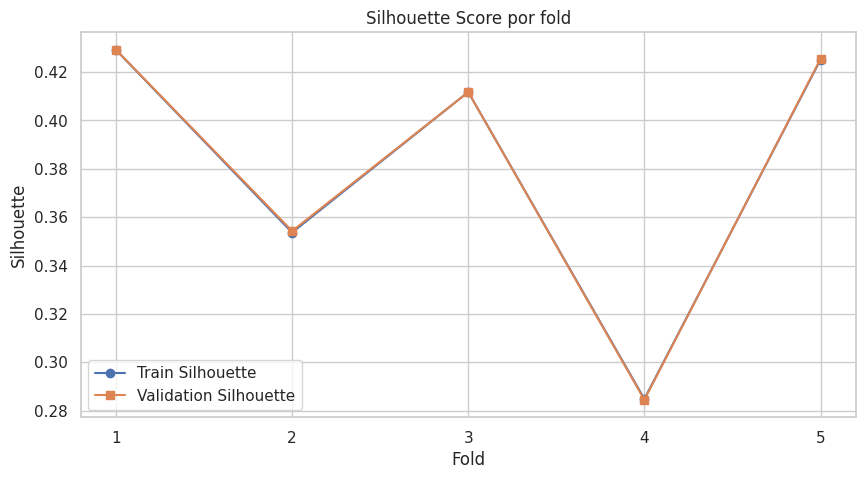

In [16]:

# 4.1 Silhouette por fold (Train vs Validation)
plt.figure(figsize=(10, 5))
plt.plot(results_pd['fold'], results_pd['train_silhouette'], marker='o', label='Train Silhouette')
plt.plot(results_pd['fold'], results_pd['valid_silhouette'], marker='s', label='Validation Silhouette')
plt.xlabel('Fold')
plt.ylabel('Silhouette')
plt.title('Silhouette Score por fold')
plt.xticks(results_pd['fold'])
plt.legend()
plt.show()


La gráfica muestra que las curvas de Train Silhouette y Validation Silhouette prácticamente se superponen en los cinco folds, lo que indica una alta estabilidad del modelo y ausencia de sobreajuste. También se aprecia variabilidad entre folds: los mejores resultados se observan en los folds 1 y 5, mientras que el fold 4 presenta el valor más bajo. En conjunto, esto sugiere que el modelo generaliza bien, aunque la calidad del agrupamiento cambia según la partición evaluada.

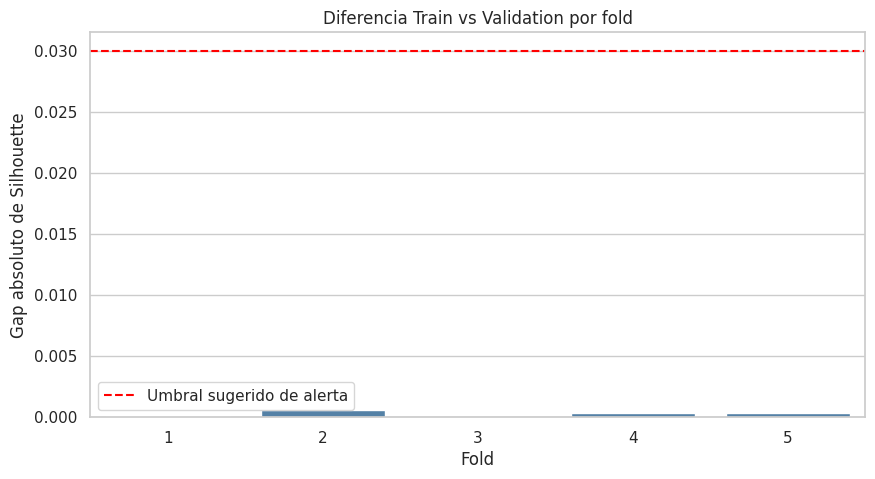

In [17]:

# 4.2 Gap Train vs Validation
plt.figure(figsize=(10, 5))
sns.barplot(data=results_pd, x='fold', y='gap_silhouette', color='steelblue')
plt.axhline(0.03, color='red', linestyle='--', label='Umbral sugerido de alerta')
plt.xlabel('Fold')
plt.ylabel('Gap absoluto de Silhouette')
plt.title('Diferencia Train vs Validation por fold')
plt.legend()
plt.show()


La gráfica muestra que el gap absoluto de Silhouette es prácticamente cero en todos los folds y se mantiene muy por debajo del umbral de alerta de 0.03. Esto confirma que el modelo presenta una excelente estabilidad entre entrenamiento y validación y que no hay evidencia de sobreajuste. En consecuencia, las diferencias observadas en desempeño entre folds se deben más a la variabilidad propia de la partición que a problemas de generalización del modelo.

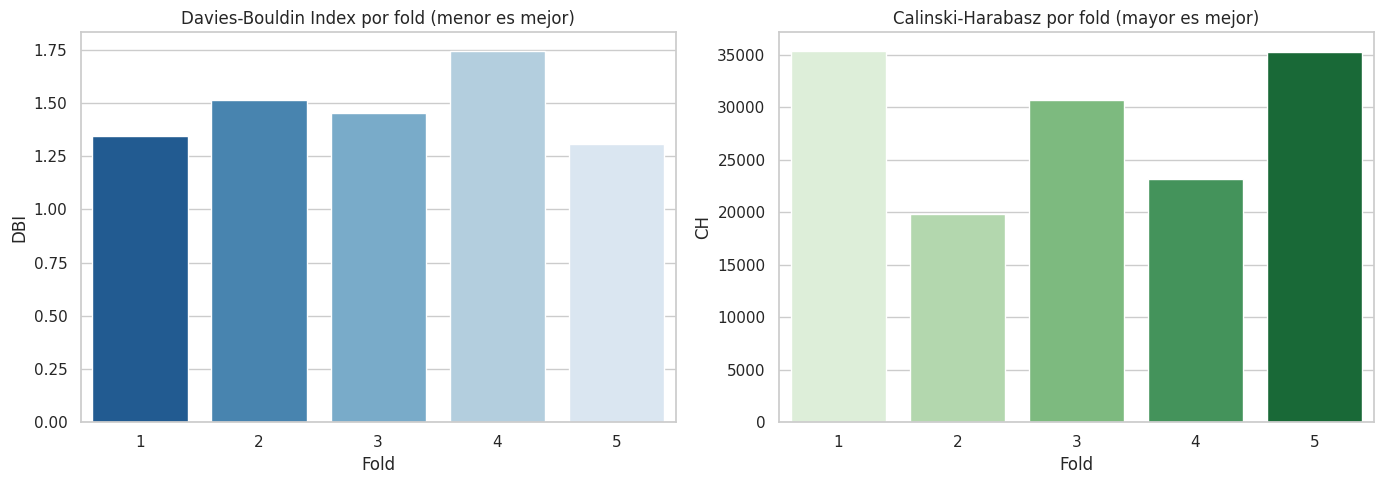

In [18]:

# 4.3 Métricas externas por fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_pd, x='fold', y='dbi_valid', palette='Blues_r', ax=axes[0])
axes[0].set_title('Davies-Bouldin Index por fold (menor es mejor)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('DBI')
sns.barplot(data=results_pd, x='fold', y='ch_valid', palette='Greens', ax=axes[1])
axes[1].set_title('Calinski-Harabasz por fold (mayor es mejor)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('CH')
plt.tight_layout()
plt.show()


Las métricas Davies-Bouldin y Calinski-Harabasz refuerzan lo observado con Silhouette. Los folds 1 y 5 presentan mejor calidad de agrupamiento, ya que combinan DBI más bajo y CH más alto, mientras que el fold 4 muestra el comportamiento menos favorable. En conjunto, ambas métricas confirman que existe variabilidad entre folds, pero mantienen una interpretación consistente sobre cuáles particiones generan clusters más compactos y mejor separados.

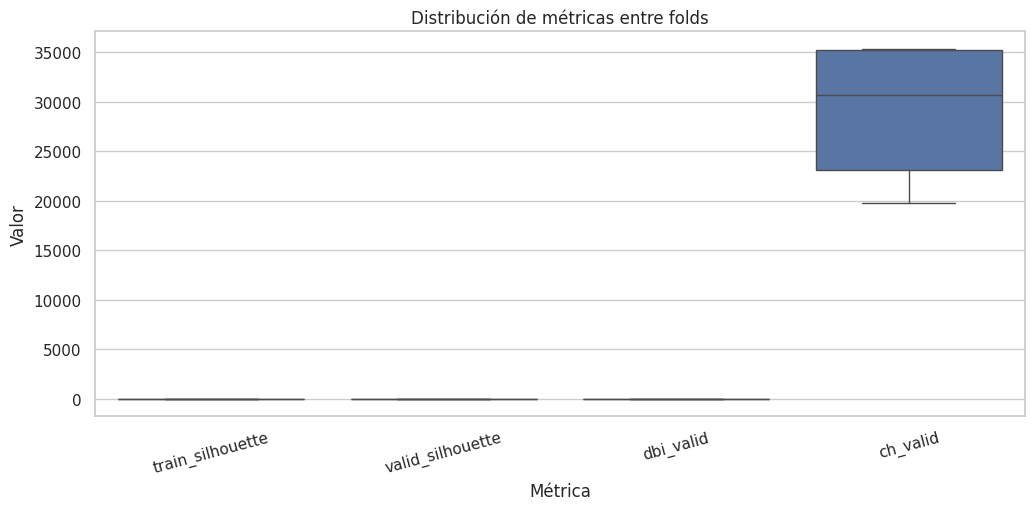

In [19]:

# 4.4 Boxplot de variabilidad de métricas
melted = results_pd.melt(id_vars=['fold'], value_vars=['train_silhouette', 'valid_silhouette', 'dbi_valid', 'ch_valid'], var_name='metric', value_name='value')
plt.figure(figsize=(12, 5))
sns.boxplot(data=melted, x='metric', y='value')
plt.title('Distribución de métricas entre folds')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.xticks(rotation=15)
plt.show()


El boxplot muestra que las métricas presentan distinta variabilidad entre folds. Los valores de train_silhouette, valid_silhouette y dbi_valid se concentran en rangos relativamente acotados, mientras que ch_valid exhibe una dispersión mucho mayor. Esto indica que la estabilidad del modelo es alta en términos de Silhouette y DBI, pero que el índice Calinski-Harabasz es más sensible a la composición de cada fold.

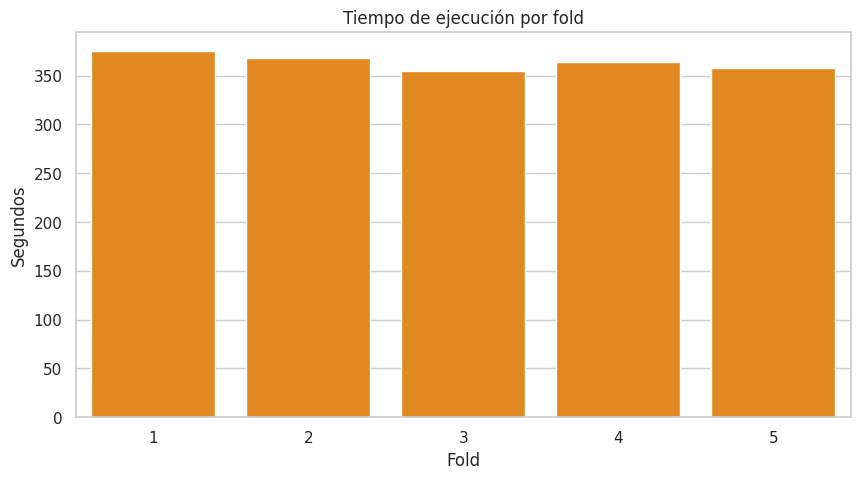

In [20]:

# 4.5 Complejidad computacional: tiempo por fold
plt.figure(figsize=(10, 5))
sns.barplot(data=results_pd, x='fold', y='runtime_sec', color='darkorange')
plt.xlabel('Fold')
plt.ylabel('Segundos')
plt.title('Tiempo de ejecución por fold')
plt.show()


La gráfica muestra que el tiempo de ejecución se mantiene muy uniforme en los cinco folds, con valores cercanos entre sí y sin diferencias importantes. Esto indica que el procedimiento de validación cruzada es computacionalmente estable y que el costo de entrenamiento del modelo en PySpark es consistente entre iteraciones.

In [21]:

# 4.6 Tabla de resumen final
summary_metrics


,métrica,media,desv_std,mínimo,máximo,coef_var_pct
0,train_silhouette,3.809218e-01,0.061672,2.848372e-01,4.291965e-01,16.190214
1,valid_silhouette,3.810515e-01,0.061817,2.844772e-01,4.292661e-01,16.222719
2,gap_silhouette,2.830928e-04,0.000243,2.349338e-05,6.194593e-04,85.731041
3,dbi_valid,1.473583e+00,0.172532,1.309181e+00,1.745457e+00,11.708358
4,ch_valid,2.885326e+04,7078.076608,1.981104e+04,3.535825e+04,24.531289
5,training_cost,2.456523e+06,337771.566931,2.156227e+06,2.909520e+06,13.749984
6,runtime_sec,3.639567e+02,8.396690,3.544418e+02,3.756304e+02,2.307058


El resumen estadístico confirma que el modelo presenta una generalización muy estable, ya que los valores promedio de train_silhouette y valid_silhouette son prácticamente iguales (0.3809 y 0.3811), y el gap promedio es casi nulo (0.000283). Al mismo tiempo, la desviación estándar del Silhouette indica una variabilidad moderada entre folds, por lo que el desempeño del modelo cambia según la partición evaluada. En cuanto al costo computacional, tanto el training cost como el tiempo de ejecución se mantienen en rangos consistentes, lo que respalda la estabilidad operativa del proceso experimental.


# 5. Discusión y conclusiones

**Discusión**

La validación cruzada estratificada de 5 folds permitió evaluar de manera más rigurosa la estabilidad del modelo K-Means con K = 5, previamente identificado como el mejor algoritmo en la Etapa 3 del proyecto. En esa etapa, dicho modelo obtuvo un Silhouette Score en TEST de 0.4267, superando a Bisecting K-Means, por lo que fue razonable utilizarlo como base para esta actividad.
Los resultados obtenidos en esta nueva fase confirman que el modelo presenta una excelente capacidad de generalización, ya que la diferencia entre las métricas de entrenamiento y validación fue prácticamente nula en los cinco folds. En promedio, el train_silhouette fue de 0.3809, mientras que el valid_silhouette fue de 0.3811, con un gap promedio de apenas 0.000283. Estos valores muestran que los patrones aprendidos durante el entrenamiento se mantienen al evaluar el modelo sobre datos no utilizados para ajustarlo, lo cual constituye una evidencia clara de que no existe sobreajuste relevante.
No obstante, la validación cruzada también mostró que la calidad del agrupamiento sí varía entre particiones. El Silhouette de validación osciló entre 0.2845 y 0.4293, con una desviación estándar de 0.0618, lo que indica una variabilidad moderada entre folds. En particular, los folds 1 y 5 presentaron los mejores resultados, mientras que el fold 4 fue el menos favorable.
Las métricas complementarias refuerzan esta interpretación. El Davies-Bouldin Index promedio fue de 1.4736, con mejores valores en los folds 1 y 5, mientras que el índice Calinski-Harabasz alcanzó una media de 28,853.26, presentando también sus mejores niveles en los folds más favorables. Esta consistencia entre Silhouette, DBI y CH fortalece la validez de la evaluación, ya que las tres métricas coinciden en identificar cuáles particiones generan clusters más compactos y mejor separados.

Desde una perspectiva metodológica, estos resultados son especialmente valiosos porque muestran que el desempeño observado en la Etapa 3, basado en una sola partición Train/Test, era consistente pero no representaba necesariamente el comportamiento promedio del modelo. La validación cruzada permitió obtener una visión más completa y robusta del desempeño esperado, reduciendo la dependencia de una sola partición y proporcionando una mejor estimación de la variabilidad real del algoritmo.

**Conclusiones**

Con base en la evidencia obtenida, se concluye que el modelo K-Means con K = 5 es una alternativa pertinente para la tarea de clustering desarrollada en este proyecto. La validación cruzada mostró que el modelo posee muy buena capacidad de generalización, una variabilidad moderada pero aceptable entre folds, y una consistencia clara entre métricas de evaluación. En conjunto, estos resultados permiten afirmar que el algoritmo captura patrones relevantes en la muestra analizada y que su comportamiento es suficientemente robusto para este problema de Big Data.

Asimismo, el proceso experimental fue computacionalmente estable, ya que el tiempo de ejecución osciló entre 354.44 y 375.63 segundos, con una media de 363.96 segundos y un coeficiente de variación de apenas 2.31%. Esto demuestra que, además de ser metodológicamente válido, el procedimiento es viable desde el punto de vista operativo en un entorno PySpark.
En síntesis, la validación cruzada estratificada permitió pasar de una evaluación basada en una sola partición a una evaluación más robusta y confiable. Gracias a ello, puede sostenerse con mayor fundamento que K-Means con K = 5 representa una solución estable, escalable y metodológicamente consistente para el análisis de agrupamientos en el contexto del dataset trabajado.
